In [718]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial import ConvexHull

from src.colorconv import ConvexCluster
from src.util import (plot_color_grid,
                      degree_of_convexity_cielab)

sns.set(context='paper', 
        style='ticks', 
        font_scale=1.1,
        font='serif',
        )

In [719]:
# unpockle IB_color_naming.pkl from data
with open('data/IB_color_naming.pkl', 'rb') as f:
    IB_color_naming = pickle.load(f)

# unpickle chip dict
with open('data/chip_dict.pkl', 'rb') as f:
    chip_dict = pickle.load(f)

# unpickle sielab_dict
with open('data/cielab_dict.pkl', 'rb') as f:
    cielab_dict = pickle.load(f)   

# unpickle rgb_dict
with open('data/rgb_dict.pkl', 'rb') as f:
    rgb_dict = pickle.load(f)

# unpickle languages
with open('data/lg_color.pkl', 'rb') as f:
    lg_color = pickle.load(f)

# unpickle lang_info
with open('data/lang_info.pkl', 'rb') as f:
    lang_info = pickle.load(f)

# unpickle pM
with open('data/pM.pkl', 'rb') as f:
    p_m = pickle.load(f)

In [720]:
# Extract coordinates and colors from the dictionary
coordinates = list(rgb_dict.keys())
colors = [rgb_dict[coord] for coord in coordinates]

# Convert RGB values to valid color format understood by Matplotlib
colors = [(r, g, b) for r, g, b in colors]

grid_size = (max(coord[0] for coord in coordinates) + 1, 
             max(coord[1] for coord in coordinates) + 1)
image = np.zeros((grid_size[0], grid_size[1], 3))

# Assign colors to pixels
for coord, color in zip(coordinates, colors):
    image[coord[0], coord[1]] = color

# fill empty pixels with white
image[image.sum(axis=2) == 0] = (1, 1, 1)

In [721]:
CIELAB_c = dict()

for coord in cielab_dict:
    CIELAB_c[cielab_dict[coord]] = image[coord[0]+1, coord[1]+1]


# Extract coordinates and colors from the dictionary
coordinates = list(CIELAB_c.keys())

In [722]:
# only choose coordinates in the range (0, 0), (8, 40)
cielab_dict_ = {k: v for k, v in cielab_dict.items() if k[0] in range(-1, 9) and k[1] in range(-1, 41)}

# reverse keys and values in cielab_dict_
cielab_dict_r = {v: k for k, v in cielab_dict_.items()}

# convert cielab_dict_ to a list of tuples ordered from (0, 0) to (8, 40)
cielab_list = [cielab_dict_[k] for k in sorted(cielab_dict_.keys())]

In [723]:
prior_m = IB_color_naming['pM']

# match index of prior_m to chip_dict coordinates 
# and build a new dict (coordinate: probability)
prior_m_ = []
for i, p in enumerate(prior_m):
    prior_m_.append((chip_dict[i+1], p))

# remove entries with first coordinate == 1
# prior_m_ = [x for x in prior_m_ if x[0][1] != 0]
prior_m_ = [x for x in prior_m_]

# use coordinate from prior_m_ to build a matrix with probabilities
prior_m_matrix = np.zeros((10, 41))
for c, p in prior_m_:
    # prior_m_matrix[c[0]-1, c[1]-1] = p
    prior_m_matrix[c[0]-1, c[1]-1] = p

prior_m_matrix = np.vstack((prior_m_matrix[-1, :], prior_m_matrix[:-1, :]))
# move the last column first
prior_m_matrix = np.hstack((prior_m_matrix[:, -1][:, np.newaxis], prior_m_matrix[:, :-1]))

In [724]:
p_m = np.ones(330) / 330
# add one dimension to p_m
p_m = p_m[:, np.newaxis]

In [725]:
a = ConvexCluster(X = np.zeros((10, 41)), 
                    d = 10, 
                    N = 3, 
                    s = 1, 
                    c = 1e-20,
                    coords = cielab_list,
                    reverse_labels = cielab_dict_r,
                    p = p_m)
labels = a.run()
labels = np.vstack((labels[-1, :], labels[:-1, :]))
labels = np.hstack((labels[:, -1][:, np.newaxis], labels[:, :-1]))

In [726]:
a.degree_of_convexity()

1.0

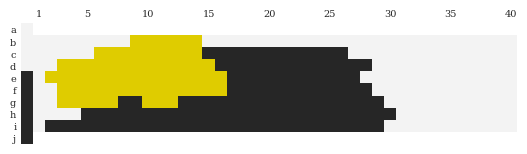

In [727]:
img = plot_color_grid(labels, rgb_dict, prior_m_matrix)
plt.imshow(img, interpolation='none')
plt.xticks(ticks=[1] + list(range(5, img.shape[1], 5)), 
           labels=[1] + list(range(5, img.shape[1], 5)), 
           fontsize=7)
# yticks should be letters from a to 10th letter
plt.yticks(ticks=np.arange(img.shape[0]), 
           labels=[chr(i) for i in range(97, 97+img.shape[0])], 
           fontsize=7)
plt.gca().xaxis.tick_top()
# remove all spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)
plt.gca().spines['left'].set_visible(False)
# remove tick marks
plt.gca().tick_params(axis='both', which='both', length=0)
plt.show()

In [728]:
# convert img to a flat list of colors excluding white pixels
colors = [img[i, j] for i in range(img.shape[0]) 
                   for j in range(img.shape[1]) 
                   if not np.allclose(img[i, j], [1.0, 1.0, 1.0])]

In [729]:
# match coordinates to colors to get color per coordinate
colors_dict = dict()
for coord, color in zip(cielab_list, colors):
    colors_dict[coord] = color


In [730]:
len(colors) == len(coordinates)

True

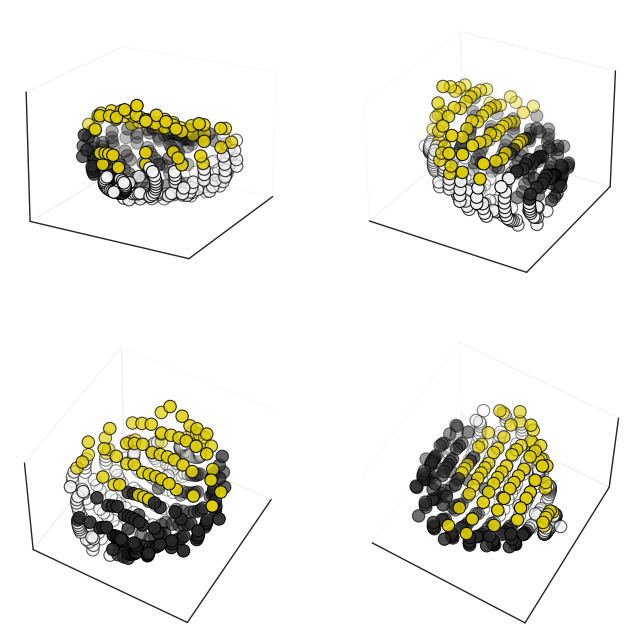

In [731]:
fig = plt.figure(figsize=(8, 8))

# Define the subplots (2x2 grid)
ax1 = fig.add_subplot(221, projection='3d')
ax2 = fig.add_subplot(222, projection='3d')
ax3 = fig.add_subplot(223, projection='3d')
ax4 = fig.add_subplot(224, projection='3d')

# Remove the pane fills for all subplots
for ax in [ax1, ax2, ax3, ax4]:
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])
    
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False

    # Add axis labels for CIELAB coordinates
    # ax.set_zlabel('L*', fontsize=10)
    # ax.set_xlabel('a*', fontsize=10)
    # ax.set_ylabel('b*', fontsize=10)

# Set different views for each subplot
ax1.view_init(elev=20, azim=30)  # Rotation 1
ax2.view_init(elev=30, azim=120)  # Rotation 2
ax3.view_init(elev=50, azim=210)  # Rotation 3
ax4.view_init(elev=60, azim=300)  # Rotation 4

# Scatter plots with the same data
ax1.scatter(*zip(*coordinates), s=80, marker='o', c=colors, edgecolors='black')
ax2.scatter(*zip(*coordinates), s=80, marker='o', c=colors, edgecolors='black')
ax3.scatter(*zip(*coordinates), s=80, marker='o', c=colors, edgecolors='black')
ax4.scatter(*zip(*coordinates), s=80, marker='o', c=colors, edgecolors='black')

# remove grids
ax1.grid(False)
ax2.grid(False)
ax3.grid(False)
ax4.grid(False)


# plt.tight_layout()
# Display the plot
plt.show()

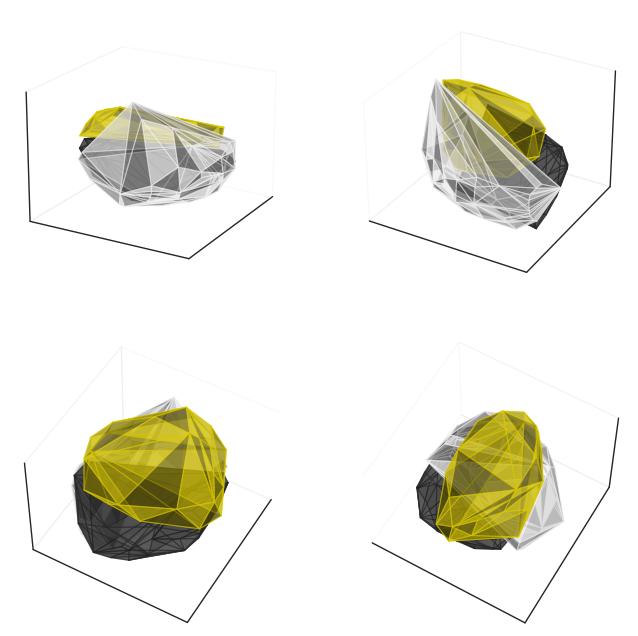

In [732]:
# unique_colors, idx = np.unique(colors, axis=0, return_index=True)
# unique_colors = unique_colors[np.argsort(idx)]
# unique_colors = np.unique(colors, axis=0)

# Create a figure with a 2x2 grid of subplots
fig = plt.figure(figsize=(8, 8))

# Define the 4 subplots (3D projections)
ax1 = fig.add_subplot(221, projection='3d')
ax2 = fig.add_subplot(222, projection='3d')
ax3 = fig.add_subplot(223, projection='3d')
ax4 = fig.add_subplot(224, projection='3d')

# List of axes for convenience
axes = [ax1, ax2, ax3, ax4]

# Remove the pane fills for each subplot
for ax in axes:
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False

# Plot convex hulls for each category
for i, cat in enumerate(sorted(np.unique(labels))):
    coords = np.array([cielab_dict_[k] for k in sorted(cielab_dict_.keys()) if labels[k] == cat])

    if len(coords) > 0:
        color = colors_dict[tuple(coords[0])]

        try:
            hull = ConvexHull(coords)
            # Plot the convex hull on each subplot
            for ax in axes:
                ax.plot_trisurf(coords[:, 0], coords[:, 1], coords[:, 2], 
                                triangles=hull.simplices, alpha=0.5, 
                                edgecolor=color, color=color,
                                antialiased=True)
        except:
            pass
    # else:
    #     # just a scatter
    #     # Get coordinates for current category
    #     coords = np.array([cielab_dict_[k] for k in sorted(cielab_dict_.keys()) if labels[k] == cat])

    #     # Plot the convex hull on each subplot
    #     for ax in axes:
    #         ax.scatter(coords[:, 0], coords[:, 1], coords[:, 2], 
    #                     c=unique_colors[i], s=30, edgecolor='black')

# Set different view angles for each subplot
ax1.view_init(elev=20, azim=30)  # Rotation 1
ax2.view_init(elev=30, azim=120)  # Rotation 2
ax3.view_init(elev=50, azim=210)  # Rotation 3
ax4.view_init(elev=60, azim=300)  # Rotation 4

# remove grids
ax1.grid(False)
ax2.grid(False)
ax3.grid(False)
ax4.grid(False)

# remove axis ticks
for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])

# plt.tight_layout()

# Display the plot
plt.show()

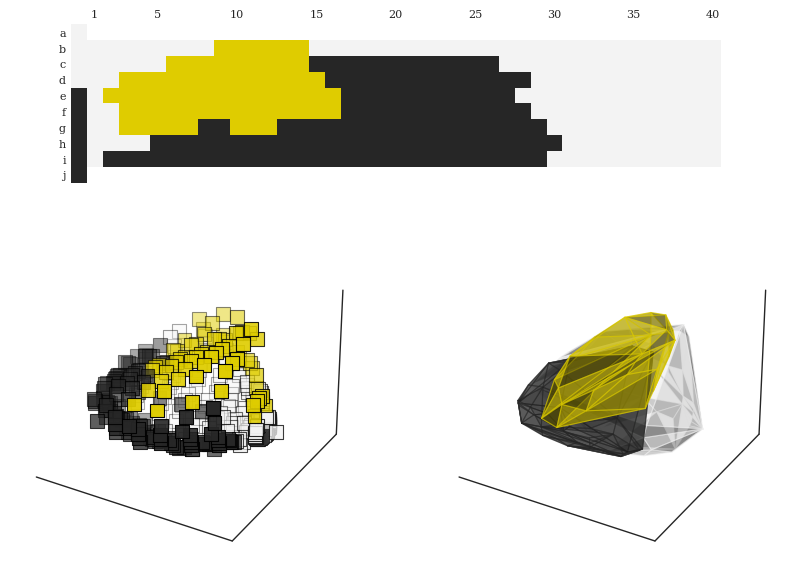

In [733]:
# Create a single figure
fig = plt.figure(figsize=(10, 7))

# Top plot: color grid
ax_top = plt.subplot2grid((3, 1), (0, 0), rowspan=1)
img = plot_color_grid(labels, rgb_dict, prior_m_matrix)
ax_top.imshow(img, interpolation='none')
ax_top.set_xticks([1] + list(range(5, img.shape[1], 5)))
ax_top.set_xticklabels([1] + list(range(5, img.shape[1], 5)), fontsize=8)
ax_top.set_yticks(np.arange(img.shape[0]))
ax_top.set_yticklabels([chr(i) for i in range(97, 97+img.shape[0])], fontsize=8)
ax_top.xaxis.tick_top()

# Remove spines and tick marks
for spine in ax_top.spines.values():
    spine.set_visible(False)
ax_top.tick_params(axis='both', which='both', length=0)

# Bottom plots: side-by-side 3D scatter and hulls
ax1 = plt.subplot2grid((3, 2), (1, 0), rowspan=2, projection='3d')
ax2 = plt.subplot2grid((3, 2), (1, 1), rowspan=2, projection='3d')

# Plot points
ax1.scatter(*zip(*coordinates), 
            s=100, 
            marker='s', 
            c=colors, 
            # depthshade=False,
            edgecolors='black')
for axis in [ax1.xaxis, ax1.yaxis, ax1.zaxis]:
    axis.pane.set_visible(False)
ax1.set_xticks([])
ax1.set_yticks([])
ax1.set_zticks([])
ax1.grid(False)

# Plot convex hulls
for cat in sorted(np.unique(labels)):
    coords = np.array([cielab_dict_[k] for k in sorted(cielab_dict_.keys()) if labels[k] == cat])
    if len(coords) > 0:
        color = colors_dict.get(tuple(coords[0]), 'gray')
        try:
            hull = ConvexHull(coords)
            ax2.plot_trisurf(coords[:, 0], coords[:, 1], coords[:, 2],
                             triangles=hull.simplices, alpha=0.5,
                             edgecolor=color, color=color, antialiased=True)
        except Exception:
            pass
for axis in [ax2.xaxis, ax2.yaxis, ax2.zaxis]:
    axis.pane.set_visible(False)
ax2.set_xticks([])
ax2.set_yticks([])
ax2.set_zticks([])
ax2.grid(False)

# plt.tight_layout()
plt.savefig('figures/Figure_2bis.pdf', dpi=300, bbox_inches='tight')
plt.show()